Seurat VS Scanpy
----------------

In this notebook we make a comparison between Seurat's FindAllMarkers and Scanpy's rank_genes_groups. 

In [1]:
from nichenetpy.utils import read_csv_cols
from nichenetpy.gene_symbol import GeneAliasInfo
from nichenetpy.ann_utils import subset_ann
from nichenetpy.metrics import group_metrics

import pandas as pd
import scanpy as sc
import anndata
import matplotlib.pyplot as plt
import os
import requests

get the AnnData object

In [2]:
data_path = os.path.normpath("./tutorial_files/AnnData")
os.makedirs(data_path, exist_ok=True)
filename = "annData3531889.h5"
file_path = os.path.join(data_path, filename)
if not os.path.exists(file_path):
    res = requests.get(f"https://zenodo.org/records/15574665/files/{filename}")
    with open(file_path, "wb") as file:
        file.write(res.content)

In [3]:
geneinfo_path = os.path.normpath("./tutorial_files/geneinfo")
os.makedirs(geneinfo_path, exist_ok=True)
for filename in (
    "geneinfo.csv",
    "geneinfo_alias_human.csv",
    "geneinfo_alias_mouse.csv"
):
    file_path = os.path.join(geneinfo_path, filename)
    if not os.path.exists(file_path):
        res = requests.get(f"https://zenodo.org/records/20395877/files/{filename}")
        with open(file_path, "wb") as file:
            file.write(res.content)

get the seuratv5 DE_table

In [4]:
data = read_csv_cols("./data/DE_table_seuratv5.csv")
DE_table_seurat = pd.DataFrame({
    "gene": data["gene"],
    "lfc": [float(x) for x in data["avg_log2FC"]],
    "pval": [float(x) for x in data["p_val"]],
    "pval_adj": [float(x) for x in data["p_val_adj"]]
})
DE_table_seurat.index = DE_table_seurat["gene"]
DE_table_seurat.drop(columns={"gene"}, inplace=True)

compute the scanpy DE_table

In [5]:
ann = anndata.io.read_h5ad(os.path.join(data_path, "annData3531889.h5"))
mouse_alias_info = GeneAliasInfo(os.path.join(geneinfo_path, "geneinfo_alias_mouse.csv"))
mouse_alias_info.alias_to_symbol(ann)
ann_receiver = subset_ann(ann, "CD8 T", layers=["data"])
sc.tl.rank_genes_groups(
    ann_receiver,
    groupby="aggregate",
    method="wilcoxon",
    layer="data",
    groups=["LCMV"], 
    reference="SS"
)
res = ann_receiver.uns["rank_genes_groups"]
DE_table_scanpy = pd.DataFrame({
    "gene": [x[0] for x in res["names"]],
    "lfc": [x[0] for x in res["logfoldchanges"]],
    "pval": [x[0] for x in res["pvals"]],
    "pval_adj": [x[0] for x in res["pvals_adj"]]
})
DE_table_scanpy.index = DE_table_scanpy["gene"]
DE_table_scanpy.drop(columns={"gene"}, inplace=True)

compute the custom DE_table (custom should reproduce the results from seuratv5)

In [6]:
pd.options.mode.chained_assignment = None # false positive warnings removal
group_metrics(
    ann_receiver,
    groupby="aggregate",
    layer="data",
    min_abs_lfc=0.25,
    min_pct=0.05
)
DE_table_custom = ann_receiver.uns["group_metrics"]
DE_table_custom = DE_table_custom[DE_table_custom["aggregate"] == "LCMV"]
DE_table_custom.index = DE_table_custom["gene"]
DE_table_custom.drop(columns={"gene", "aggregate", "pct"}, inplace=True)
DE_table_custom.drop_duplicates(inplace=True)

combine the tables

In [7]:
DE_table_custom.rename(
    columns=lambda x : f"{x}_custom",
    inplace=True
)
DE_table = DE_table_seurat.join(
    DE_table_scanpy,
    how="inner",
    lsuffix="_seurat",
    rsuffix="_scanpy"
).join(DE_table_custom, how="inner")

In [8]:
def plot_diff(
    xs,
    ys,
    title,
    xlabel,
    ylabel,
    figsize=(5, 5),
    axis_range=None
):
    figsize = (5, 5)
    min_x = min(xs)
    max_x = max(xs)
    min_y = min(ys)
    max_y = max(ys)
    mn = min(min_x, min_y)
    mx = max(max_x, max_y)
    fig, ax = plt.subplots(figsize=figsize)
    ax.plot(xs, ys, "b.", markersize=1)
    ax.set_aspect('equal', adjustable='box')
    ax.plot((mn, mx), (mn, mx), "r-")
    if axis_range is not None:
        ax.set_xlim(-axis_range, axis_range)
        ax.set_ylim(ax.get_xlim())
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    return (fig, ax)

The following plot shows that Seurat and Scanpy compute different log fold changes. Notably Seurat has no log fold changes close to 0. 

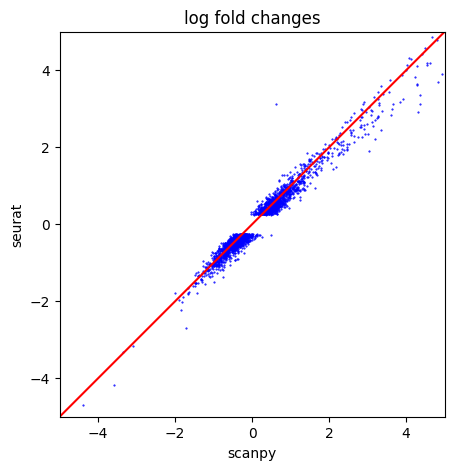

In [9]:
fig, ax = plot_diff(
    DE_table["lfc_scanpy"],
    DE_table["lfc_seurat"],
    title="log fold changes",
    xlabel="scanpy",
    ylabel="seurat",
    axis_range=5
)
plt.show()

Seurat v4 computes the log fold changes as follows

<img src="./images/SeuratVSScanpy/lfcr.png" style="width:70.0%" />

To avoid taking the log of 0, a pseudocount is added. This pseudocount is too large. 
log(x+1/y+1) is similar to log(x/y) if both x and y are sufficiently large. 
Yig can be very small however…
In Seurat v5 the problem has been mitigated by adding the pseudocount before the division. 

Scanpy computes the log fold changes as follows

<img src="./images/SeuratVSScanpy/lfcp.png" style="width:70.0%" />

exp is not applied to Yig before taking the sum and since the Yig values are logarithmic, the geometric mean of the (Xig / Si + 1) values is in fact computed. There's a -1 after the exponentiation because the mean of (Xig / Si + 1) in stead of Xig / Si values has been computed, however GM(x_0 + 1, x_1 + 1, …, x_n + 1) - 1 is not the same as GM(x_0, x_1, …, x_n). Contrary to Seurat, a small pseudocount is added which doesn't depend on the cell count, which is better. 

For more information, see

Rich JM, Moses L, Einarsson PH, Jackson K, Luebbert L, Booeshaghi AS, Antonsson S, Sullivan DK, Bray N, Melsted P, Pachter L. The impact of package selection and versioning on single-cell RNA-seq analysis. bioRxiv [Preprint]. 2024 Apr 11:2024.04.04.588111. doi: 10.1101/2024.04.04.588111. PMID: 38617255; PMCID: PMC11014608.

The following plot shows that the log fold changes computed in nichenetpy are the same as those in Seurat. 

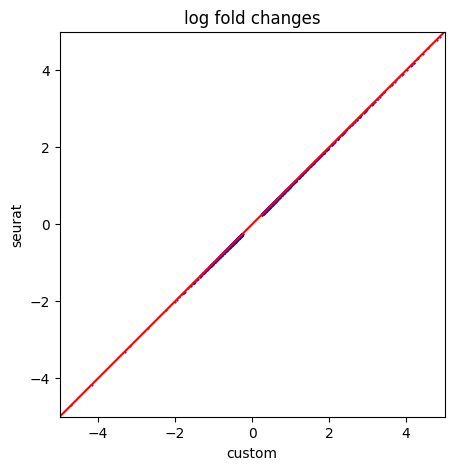

In [10]:
fig, ax = plot_diff(
    DE_table["lfc_custom"],
    DE_table["lfc_seurat"],
    title="log fold changes",
    xlabel="custom",
    ylabel="seurat",
    axis_range=5
)
plt.show()

Scanpy has significantly larger p-values than Seurat. This is because Seurat uses "Bonferroni correction" and has mandatory tie correction. Scanpy by default uses "Benjamini-Hochberg correction" and has no tie correction. Scanpy allows for Bonferroni correction and tie correction by providing corr_method="bonferroni" and tie_correct=True to rank_genes_groups. Scanpy will then produce the same p-values. 

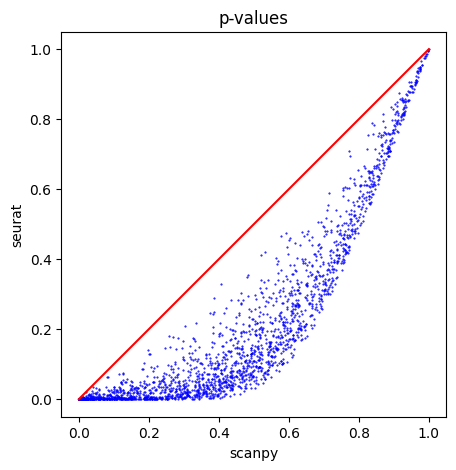

In [11]:
fig, ax = plot_diff(
    DE_table["pval_scanpy"],
    DE_table["pval_seurat"],
    title="p-values",
    xlabel="scanpy",
    ylabel="seurat"
)
plt.show()

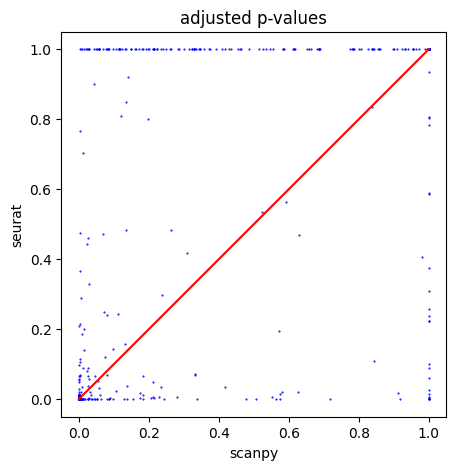

In [12]:
fig, ax = plot_diff(
    DE_table["pval_adj_scanpy"],
    DE_table["pval_adj_seurat"],
    title="adjusted p-values",
    xlabel="scanpy",
    ylabel="seurat"
)
plt.show()

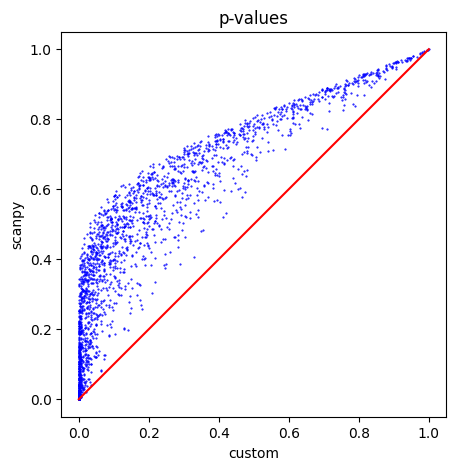

In [13]:
fig, ax = plot_diff(
    DE_table["pval_custom"],
    DE_table["pval_scanpy"],
    title="p-values",
    xlabel="custom",
    ylabel="scanpy"
)
plt.show()

The following plot shows that the wilcoxon implementation in nichenetpy produces the same p-values as Seurat

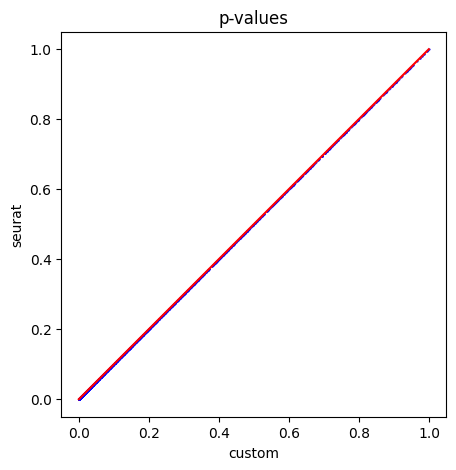

In [14]:
fig, ax = plot_diff(
    DE_table["pval_custom"],
    DE_table["pval_seurat"],
    title="p-values",
    xlabel="custom",
    ylabel="seurat"
)
plt.show()

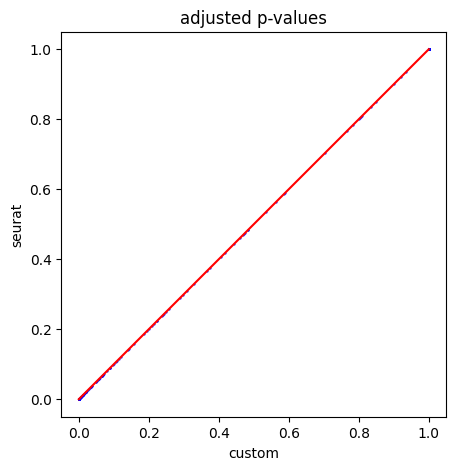

In [15]:
fig, ax = plot_diff(
    DE_table["pval_adj_custom"],
    DE_table["pval_adj_seurat"],
    title="adjusted p-values",
    xlabel="custom",
    ylabel="seurat"
)
plt.show()